# 03 — Feature Selection và Model Experiments
Theo dõi kết quả nhiều model × nhiều giá trị k bằng 5-Fold Cross-Validation.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
cwd=Path.cwd(); ROOT=cwd.parent if cwd.name.lower()=="notebooks" else cwd
SRC_DIR=ROOT/"src"
if str(SRC_DIR) not in sys.path: sys.path.append(str(SRC_DIR))
DATA_DIR=ROOT/"data"; EXPS_DIR=ROOT/"exps"; MODELS_DIR=ROOT/"models"/"sklearn"; SUBMISSIONS_DIR=ROOT/"submissions"
print("ROOT:",ROOT)
print("train.csv:",(DATA_DIR/"train.csv").exists())

ROOT: D:\house_price
train.csv: True


In [2]:
result_path=EXPS_DIR/"model_feature_experiments.csv"
if result_path.exists():
    results=pd.read_csv(result_path).sort_values("cv_rmse_mean")
    display(results.head(15))
else:
    print("Chưa có kết quả. Chạy: python src/experiment.py")

,model,feature_engineering,k,cv_rmse_mean,cv_rmse_std,fold_1,fold_2,fold_3,fold_4,fold_5
0,GradientBoosting,True,all,0.125655,0.014652,0.131493,0.133695,0.145495,0.111298,0.106293
1,GradientBoosting,True,100,0.129277,0.015410,0.131992,0.144352,0.146975,0.113738,0.109327
2,GradientBoosting,False,all,0.129542,0.017597,0.129857,0.139728,0.156387,0.114501,0.107238
3,GradientBoosting,True,80,0.129616,0.016228,0.131374,0.143919,0.150203,0.113920,0.108664
4,GradientBoosting,True,60,0.133018,0.018458,0.134235,0.147935,0.157586,0.117535,0.107797
5,ElasticNet,True,all,0.135948,0.030799,0.134557,0.129155,0.194487,0.110551,0.110991
6,Ridge,True,all,0.136042,0.026569,0.135750,0.130562,0.186190,0.114021,0.113688
7,ElasticNet,False,all,0.138399,0.032009,0.131392,0.135794,0.199409,0.109245,0.116154
8,Ridge,False,all,0.140010,0.029100,0.135488,0.135345,0.195756,0.116476,0.116983
9,RandomForest,True,100,0.141883,0.015980,0.143890,0.150999,0.165721,0.126658,0.122145


In [3]:
if result_path.exists():
    best_per_model=(results.sort_values("cv_rmse_mean").groupby("model",as_index=False).first().sort_values("cv_rmse_mean"))
    display(best_per_model[["model","feature_engineering","k","cv_rmse_mean","cv_rmse_std"]])

,model,feature_engineering,k,cv_rmse_mean,cv_rmse_std
1,GradientBoosting,True,all,0.125655,0.014652
0,ElasticNet,True,all,0.135948,0.030799
3,Ridge,True,all,0.136042,0.026569
2,RandomForest,True,100,0.141883,0.015980


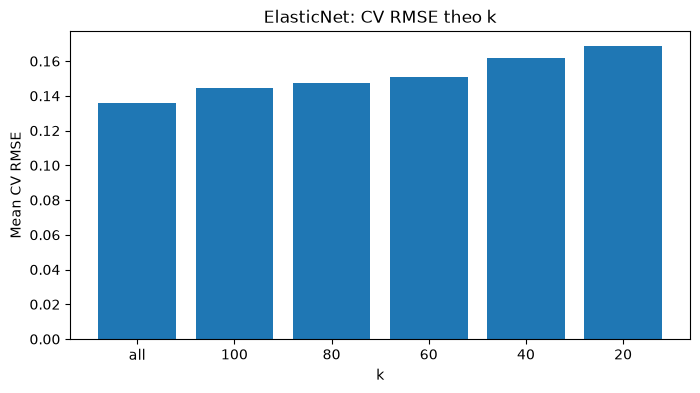

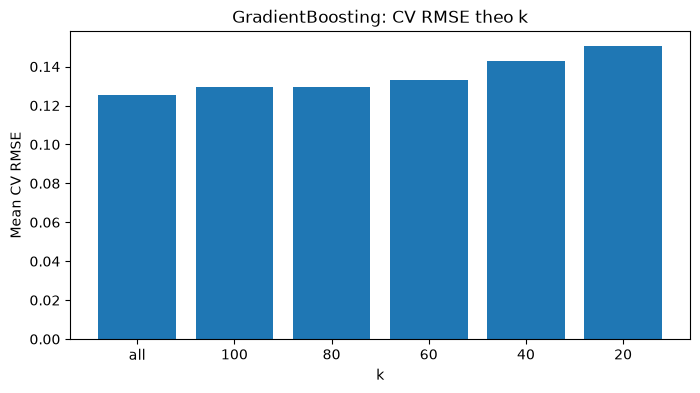

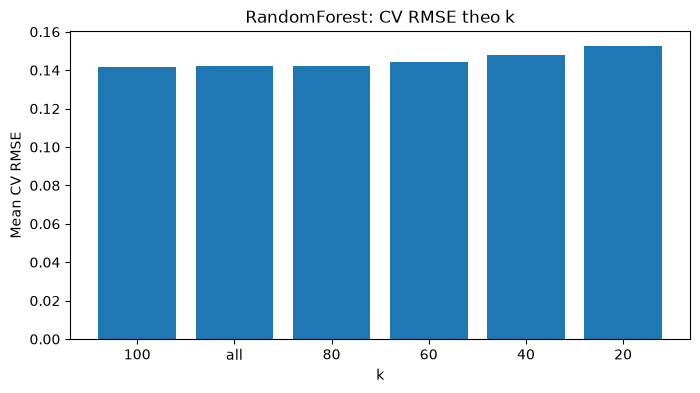

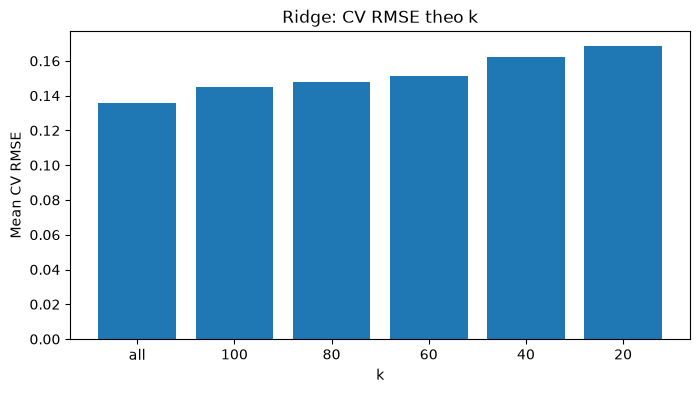

In [4]:
if result_path.exists():
    plot_df=results[results["feature_engineering"].astype(str).str.lower().eq("true")].copy()
    plot_df["k_label"]=plot_df["k"].astype(str)
    for model_name,g in plot_df.groupby("model"):
        plt.figure(figsize=(8,4)); plt.bar(g["k_label"],g["cv_rmse_mean"]); plt.title(f"{model_name}: CV RMSE theo k"); plt.xlabel("k"); plt.ylabel("Mean CV RMSE"); plt.show()

## Chạy thử một cấu hình ngay trong notebook

In [5]:
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from preprocessing import HouseDataCleaner,build_preprocessor
from feature_engineering import HouseFeatureEngineer
from feature_selection import build_feature_selector
train=pd.read_csv(DATA_DIR/"train.csv"); X=train.drop(columns=["SalePrice"]); y=train["SalePrice"]
X_dev,_,y_dev,_=train_test_split(X,y,test_size=0.2,random_state=42)
pipeline=Pipeline([("cleaner",HouseDataCleaner()),("feature_engineering",HouseFeatureEngineer()),("preprocessor",build_preprocessor()),("feature_selection",build_feature_selector(k=60)),("model",Ridge(alpha=10.0))])
cv=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(pipeline,X_dev,np.log1p(y_dev),cv=cv,scoring="neg_root_mean_squared_error",n_jobs=-1)
rmse=-scores
print("Fold RMSE:",rmse)
print("Mean:",rmse.mean())
print("Std :",rmse.std())

Fold RMSE: [0.13799643 0.1515847  0.21788134 0.1314199  0.11809683]
Mean: 0.15139583945107551
Std : 0.03495071871800648
